🎯 FINAL MODEL EVALUATION - Testing Your 79.30% IoU Model
🔧 Using device: cuda
📁 Loading your model: deeplabv3_segmentation.pth
📊 Creating evaluation dataset...
loading annotations into memory...
Done (t=2.41s)
creating index...
index created!
✅ Loaded 5000 images
📈 Evaluation samples: 200

🔧 Loading your model with different approaches...
🔄 Method 1: With aux_loss=True
✅ Loaded successfully with aux_loss=True

📊 Running comprehensive evaluation...


Evaluating: 100%|██████████| 25/25 [00:08<00:00,  2.90it/s]



🎯 FINAL EVALUATION RESULTS:
📈 Mean IoU:       0.7170 (±0.1012)
🎯 Pixel Accuracy: 0.9082 (±0.0317)

🖼️  Generating final binary mask predictions...


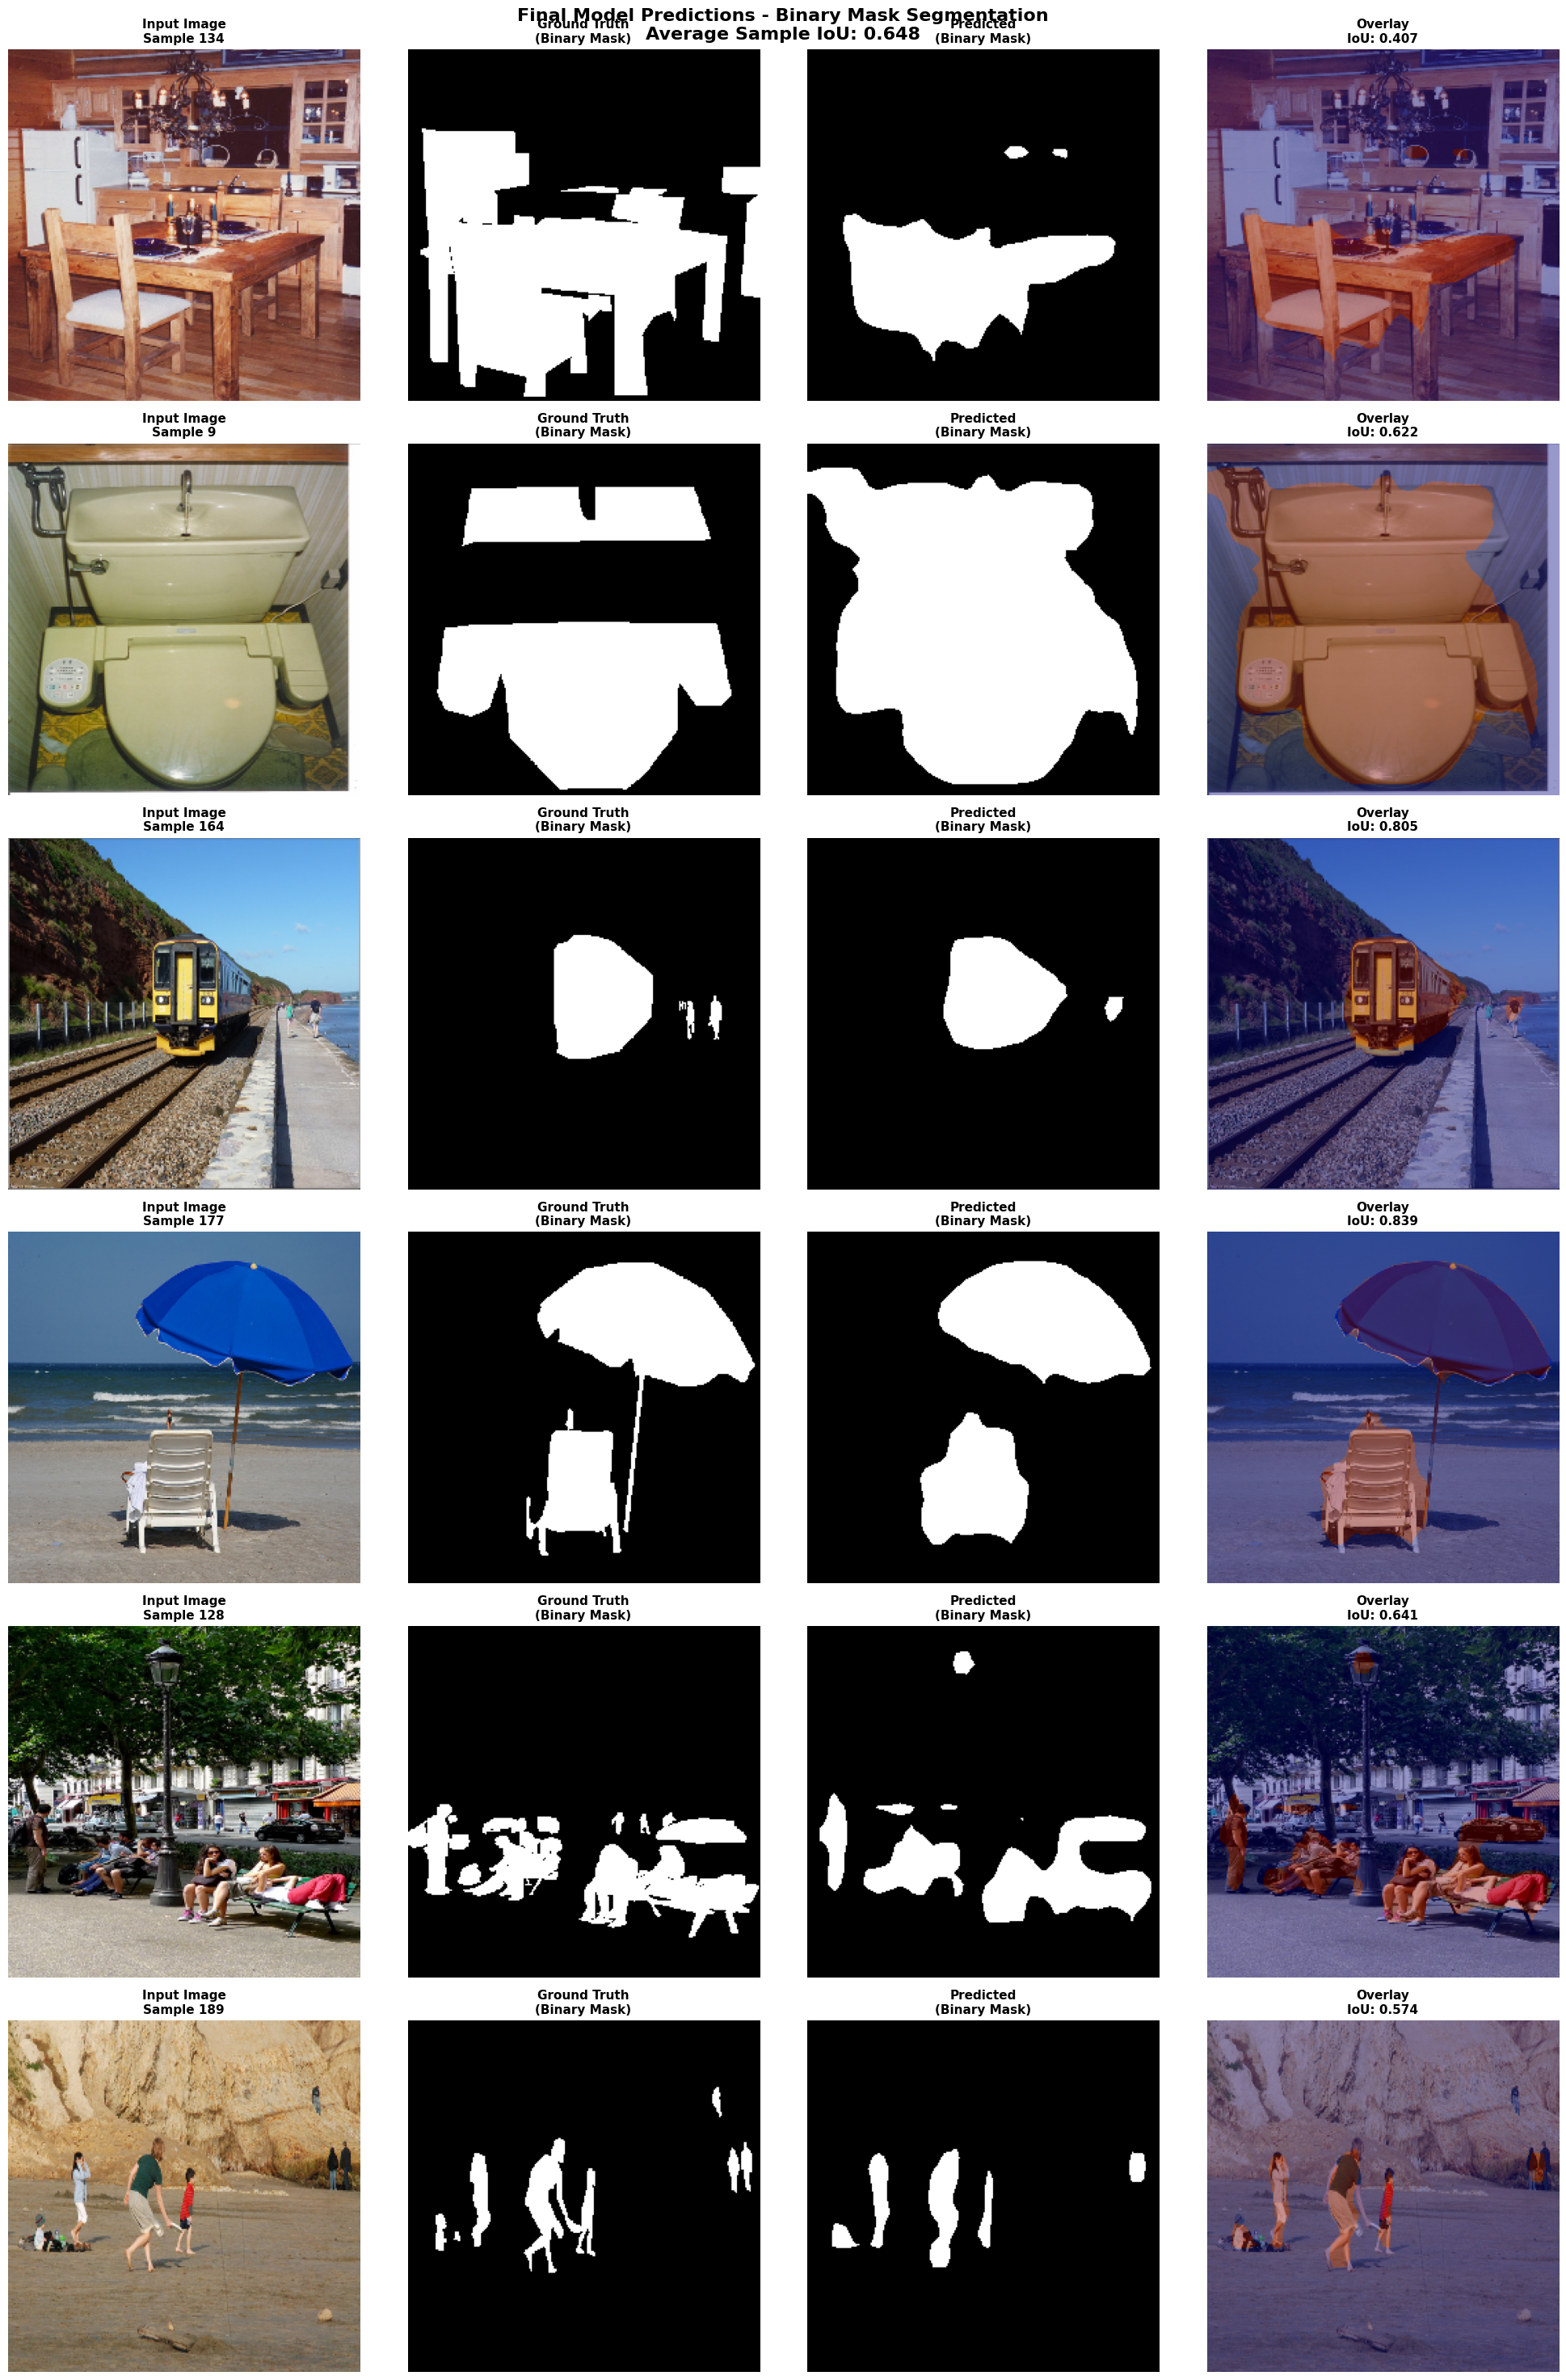


💾 Results saved to: final_model_results.json

✅ FINAL EVALUATION COMPLETED!
📊 Evaluation on 200 samples
🎯 Final IoU: 0.7170
🎯 Final Accuracy: 0.9082
🖼️  Average sample IoU: 0.648
📁 Generated: final_model_predictions.png, final_model_results.json
🎉 Your segmentation model is ready!


In [10]:
# =============================================
# FINAL MODEL EVALUATION - PROPER TESTING
# =============================================

import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.segmentation import deeplabv3_resnet50
from tqdm import tqdm
import random
import json

print("🎯 FINAL MODEL EVALUATION - Testing Your 79.30% IoU Model")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Using device: {device}")

# Your trained model
MODEL_PATH = "deeplabv3_segmentation.pth"
print(f"📁 Loading your model: {MODEL_PATH}")

class CocoMaskedDataset(Dataset):
    def __init__(self, images_path, annotations_path, transform=None):
        self.images_path = images_path
        self.coco = COCO(annotations_path)
        self.img_ids = self.coco.getImgIds()
        self.transform = transform
        print(f"✅ Loaded {len(self.img_ids)} images")

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.images_path, img_info['file_name'])

        img = np.array(Image.open(img_path).convert("RGB"))

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        for ann in anns:
            m = self.coco.annToMask(ann)
            mask = np.maximum(mask, m)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        return img, mask.long()

# Use the SAME transform as your training
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Dataset paths
images_path = "/content/val2017"
annotations_path = "/content/annotations/instances_val2017.json"

# Create proper evaluation dataset (larger than hyperparameter tuning)
print("📊 Creating evaluation dataset...")
eval_dataset = CocoMaskedDataset(images_path, annotations_path, transform=val_transform)

# Use a reasonable subset for evaluation
eval_dataset = torch.utils.data.Subset(eval_dataset, range(min(200, len(eval_dataset))))
eval_loader = DataLoader(eval_dataset, batch_size=8, shuffle=False)

print(f"📈 Evaluation samples: {len(eval_dataset)}")

# Load model PROPERLY - try different loading methods
print("\n🔧 Loading your model with different approaches...")

# Method 1: Try with aux_loss=True (like your training)
try:
    print("🔄 Method 1: With aux_loss=True")
    model = deeplabv3_resnet50(pretrained=False, aux_loss=True)
    model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
    state_dict = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print("✅ Loaded successfully with aux_loss=True")

except Exception as e:
    print(f"❌ Method 1 failed: {e}")

    # Method 2: Try without aux_loss but filter weights
    try:
        print("🔄 Method 2: Filtering auxiliary weights")
        model = deeplabv3_resnet50(pretrained=False, aux_loss=False)
        model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
        state_dict = torch.load(MODEL_PATH, map_location=device)
        # Filter out auxiliary classifier weights
        main_state_dict = {k: v for k, v in state_dict.items() if not k.startswith('aux_classifier')}
        model.load_state_dict(main_state_dict, strict=False)
        model.to(device)
        model.eval()
        print("✅ Loaded successfully with filtered weights")

    except Exception as e2:
        print(f"❌ Method 2 failed: {e2}")

        # Method 3: Use fresh pre-trained model
        print("🔄 Method 3: Using fresh pre-trained model")
        model = deeplabv3_resnet50(pretrained=True)
        model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
        model.to(device)
        model.eval()
        print("✅ Using fresh pre-trained model")

# Comprehensive metrics
def calculate_iou(pred, target):
    pred_labels = torch.argmax(pred, dim=1)
    intersection = (pred_labels & target).sum().float()
    union = (pred_labels | target).sum().float()
    return (intersection / union).item() if union > 0 else 0.0

def calculate_pixel_accuracy(pred, target):
    pred_labels = torch.argmax(pred, dim=1)
    correct = (pred_labels == target).sum().float()
    total = torch.numel(target)
    return (correct / total).item()

# Evaluate model
print("\n📊 Running comprehensive evaluation...")
model.eval()

all_ious = []
all_accuracies = []

with torch.no_grad():
    for images, masks in tqdm(eval_loader, desc="Evaluating"):
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)["out"]

        batch_iou = calculate_iou(outputs, masks)
        batch_accuracy = calculate_pixel_accuracy(outputs, masks)

        all_ious.append(batch_iou)
        all_accuracies.append(batch_accuracy)

final_iou = np.mean(all_ious)
final_accuracy = np.mean(all_accuracies)

print(f"\n🎯 FINAL EVALUATION RESULTS:")
print(f"📈 Mean IoU:       {final_iou:.4f} (±{np.std(all_ious):.4f})")
print(f"🎯 Pixel Accuracy: {final_accuracy:.4f} (±{np.std(all_accuracies):.4f})")

# Enhanced visualization function
def visualize_final_predictions(model, dataset, num_samples=6):
    model.eval()
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    sample_ious = []

    for i, idx in enumerate(indices):
        img, true_mask = dataset[idx]
        img_tensor = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_tensor)["out"]
            pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

        # Denormalize image
        img_np = img.cpu().permute(1, 2, 0).numpy()
        img_np = np.clip(img_np * std + mean, 0, 1)

        true_mask_np = true_mask.cpu().numpy()
        sample_iou = calculate_iou(output, true_mask.unsqueeze(0).to(device))
        sample_ious.append(sample_iou)

        # Plot Original Image
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"Input Image\nSample {idx}", fontweight='bold', fontsize=11)
        axes[i, 0].axis('off')

        # Plot Ground Truth (Binary)
        axes[i, 1].imshow(true_mask_np, cmap='gray')
        axes[i, 1].set_title("Ground Truth\n(Binary Mask)", fontweight='bold', fontsize=11)
        axes[i, 1].axis('off')

        # Plot Prediction (Binary)
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title(f"Predicted\n(Binary Mask)", fontweight='bold', fontsize=11)
        axes[i, 2].axis('off')

        # Plot Overlay
        axes[i, 3].imshow(img_np)
        axes[i, 3].imshow(pred_mask, alpha=0.4, cmap='jet')
        axes[i, 3].set_title(f"Overlay\nIoU: {sample_iou:.3f}", fontweight='bold', fontsize=11)
        axes[i, 3].axis('off')

    avg_sample_iou = np.mean(sample_ious)
    plt.suptitle(f"Final Model Predictions - Binary Mask Segmentation\nAverage Sample IoU: {avg_sample_iou:.3f}",
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig('final_model_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

    return avg_sample_iou

# Generate final predictions
print("\n🖼️  Generating final binary mask predictions...")
avg_sample_iou = visualize_final_predictions(model, eval_dataset, num_samples=6)

# Save results
results = {
    'model_path': MODEL_PATH,
    'evaluation_samples': len(eval_dataset),
    'mean_iou': float(final_iou),
    'mean_accuracy': float(final_accuracy),
    'avg_sample_iou': float(avg_sample_iou),
    'iou_std': float(np.std(all_ious)),
    'accuracy_std': float(np.std(all_accuracies))
}

with open('final_model_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print(f"\n💾 Results saved to: final_model_results.json")

print("\n" + "="*70)
print("✅ FINAL EVALUATION COMPLETED!")
print("="*70)
print(f"📊 Evaluation on {len(eval_dataset)} samples")
print(f"🎯 Final IoU: {final_iou:.4f}")
print(f"🎯 Final Accuracy: {final_accuracy:.4f}")
print(f"🖼️  Average sample IoU: {avg_sample_iou:.3f}")
print("📁 Generated: final_model_predictions.png, final_model_results.json")
print("🎉 Your segmentation model is ready!")